<a href="https://colab.research.google.com/github/ethanboyjeff/ELE2038-Coursework/blob/main/ELE2038_CW_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Equilibrium: x = 0.44 m, i = 0.5132 A, V = 1128.99 V


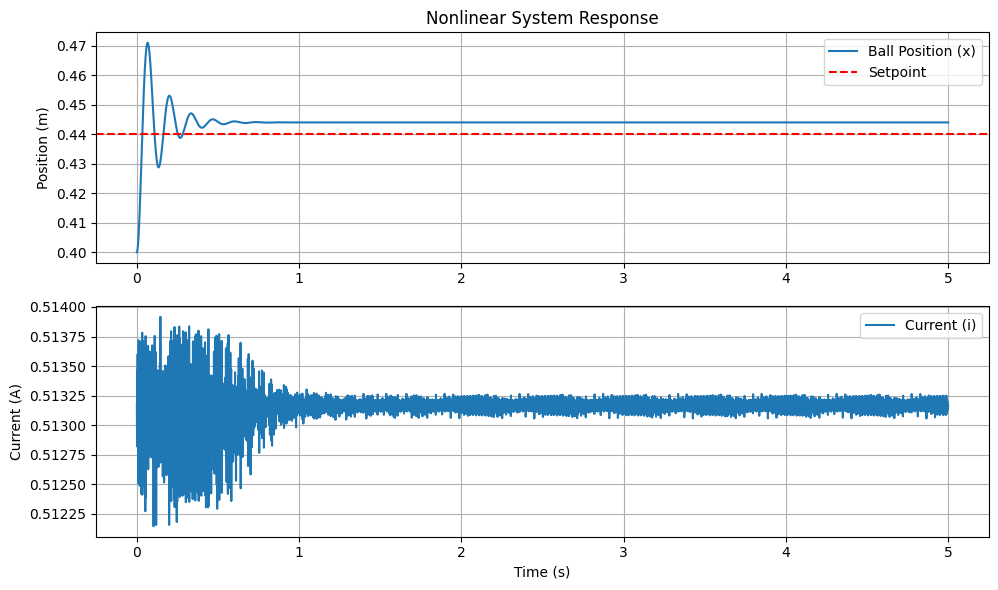

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim, TransferFunction

# 1. System Parameters
m = 0.462
g = 9.81
r = 0.123
k = 1885.0
b = 10.4
d = 0.42
delta = 0.65
phi = np.deg2rad(41) # 41 degrees
R = 2200.0
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811       # Magnetic constant
tau_m = 0.03    # Sensor time constant

# Derived effective mass for a rolling sphere
m_eq = (7/5) * m

# 2. Operating Point / Equilibrium
x_sp = 0.44     # Setpoint position (m)
# Mechanical equilibrium to find i_eq
# F_mag = mg*sin(phi) + k(x - d)
f_grav_spring = m*g*np.sin(phi) + k*(x_sp - d)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
V_eq = R * i_eq # Voltage at equilibrium

print(f"Equilibrium: x = {x_sp} m, i = {i_eq:.4f} A, V = {V_eq:.2f} V")

# 3. Nonlinear System ODEs
def system_dynamics(t, state, V_input):
    x, v, i = state

    # Distance to electromagnet
    y = delta - x

    # Mechanical ODE: m_eq*x_ddot = F_grav - k(x-d) - b*v + F_mag
    # Note: Using your report's convention for F_mag direction
    f_mag = c * i**2 / y**2
    x_dot = v
    v_dot = (m*g*np.sin(phi) - k*(x - d) - b*v + f_mag) / m_eq

    # Electrical ODE: V = R*i + L(x)*i_dot + i*(dL/dx)*v
    Lx = L0 + L1 * np.exp(-alpha * y)
    dLdx = L1 * alpha * np.exp(-alpha * y)
    i_dot = (V_input - R*i - i * dLdx * v) / Lx

    return [x_dot, v_dot, i_dot]

# 4. PID Controller Implementation
# Based on your design requirements: OS < 10%, Settling < 2s
Kp = 10000.0  # Placeholder values - tune these based on your findings
Ki = 3500.0
Kd = 500.0

def pid_control(t, state, integral_error, last_error):
    x = state[0]
    error = x_sp - x
    dt = 0.001 # Approximation for derivative

    prop = Kp * error
    integ = Ki * (integral_error + error * dt)
    deriv = Kd * (error - last_error) / dt

    V_control = V_eq + prop + integ + deriv
    return np.clip(V_control, 0, 3000), error # Clip to realistic voltage

# 5. Simulation Loop
t_span = (0, 5) # 5 seconds simulation
t_eval = np.linspace(0, 5, 5000)
# Start slightly off the setpoint to test regulation
initial_state = [0.40, 0, i_eq]

sol = solve_ivp(lambda t, y: system_dynamics(t, y, V_eq), t_span, initial_state, t_eval=t_eval)

# 6. Plotting Results
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(sol.t, sol.y[0], label='Ball Position (x)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint')
plt.ylabel('Position (m)')
plt.title('Nonlinear System Response')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(sol.t, sol.y[2], label='Current (i)')
plt.ylabel('Current (A)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()